# 03 — Paper Figures

Authoritative source for all figures in the paper. Reads exclusively from `data/processed/`.
Run `01_pipeline.ipynb` first, then `02_ml_framing.ipynb` (GPU required) to build those files.

Figures are saved as PDF + PNG to `paper/figures/`.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

ROOT      = Path("..").resolve()
PROCESSED = ROOT / "data" / "processed"
RAW       = ROOT / "data" / "raw"
FIGURES   = ROOT / "paper" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(ROOT))
from src.dictionaries import MILESTONES

# ── Figure style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 150,
    "font.size": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.alpha": 0.4,
})

FRAME_COLORS = {
    "regulation_governance":         "#2166ac",
    "risk_safety":                   "#d6604d",
    "innovation_opportunity":        "#4dac26",
    "economic_competition_labour":   "#f4a582",
    "rights_privacy":                "#762a83",
    "misinformation_integrity":      "#92c5de",
}
FRAME_LABELS = {
    "regulation_governance":         "Regulation & Governance",
    "risk_safety":                   "Risk & Safety",
    "innovation_opportunity":        "Innovation & Opportunity",
    "economic_competition_labour":   "Economic Competition & Labour",
    "rights_privacy":                "Rights & Privacy",
    "misinformation_integrity":      "Misinformation & Integrity",
}
REGIONS = ["US", "EU", "UK"]

def _save(fig: plt.Figure, name: str) -> None:
    for ext in ("pdf", "png"):
        fig.savefig(FIGURES / f"{name}.{ext}", bbox_inches="tight")
    print(f"  Saved → paper/figures/{name}.pdf")

# ── Load processed data ───────────────────────────────────────────────────────
vol       = pd.read_parquet(PROCESSED / "monthly_volume.parquet")["count"]
vol.index = vol.index.map(lambda x: pd.Period(x, freq="M") if isinstance(x, str) else x)

shares    = pd.read_parquet(PROCESSED / "monthly_frames.parquet")
event_df  = pd.read_parquet(PROCESSED / "event_studies.parquet")
reg       = pd.read_parquet(PROCESSED / "regional_frames.parquet")
cov       = pd.read_parquet(PROCESSED / "coverage_validation.parquet")
with open(PROCESSED / "coverage_stats.json") as f:
    stats = json.load(f)

# Tone aggregates (built in 01_pipeline.ipynb Section 7)
tone_monthly = pd.read_parquet(PROCESSED / "tone_monthly.parquet")["tone"]
tone_monthly.index = tone_monthly.index.map(lambda x: pd.Period(x, freq="M") if isinstance(x, str) else x)
tone_frame  = pd.read_parquet(PROCESSED / "tone_by_frame.parquet")
tone_region = pd.read_parquet(PROCESSED / "tone_by_region.parquet")

print(f"Loaded: {len(vol)} months, {vol.sum():,} articles")

Loaded: 44 months, 1,116,091 articles


## Fig 0 — Governance coverage validation

Fraction of all GenAI news that carries a governance signal, month by month.
Used in the Methods section to justify using the governance corpus as a representative sample.

  Saved → paper/figures/fig_0_coverage.pdf


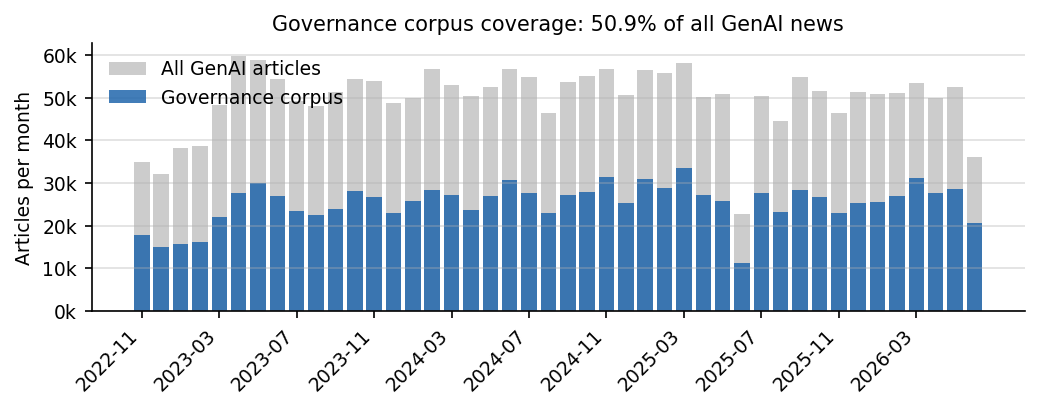

In [2]:
cov_plot = cov.copy()
cov_plot.index = cov_plot.index.map(lambda x: pd.Period(x, freq="M") if isinstance(x, str) else x)

fig, ax = plt.subplots(figsize=(7, 2.8))

x = range(len(cov_plot))
ax.bar(x, cov_plot["total_genai"], color="#cccccc", label="All GenAI articles")
ax.bar(x, cov_plot["gov_articles"], color="#2166ac", alpha=0.85, label="Governance corpus")

ax.set_xticks(x[::4])
ax.set_xticklabels([str(cov_plot.index[i]) for i in x[::4]], rotation=45, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e3:.0f}k"))
ax.set_ylabel("Articles per month")

overall = cov_plot["gov_articles"].sum() / cov_plot["total_genai"].sum()
ax.set_title(f"Governance corpus coverage: {overall:.1%} of all GenAI news", fontsize=10)
ax.legend(frameon=False)
plt.tight_layout()
_save(fig, "fig_0_coverage")
plt.show()

## Fig 1 — Monthly volume + frame prevalence

Top panel: monthly article count.  
Bottom panel: stacked area of frame prevalence rates (fraction of articles matching each frame).  
Vertical lines mark the 7 policy milestones.

  Saved → paper/figures/fig_1_volume_frames.pdf


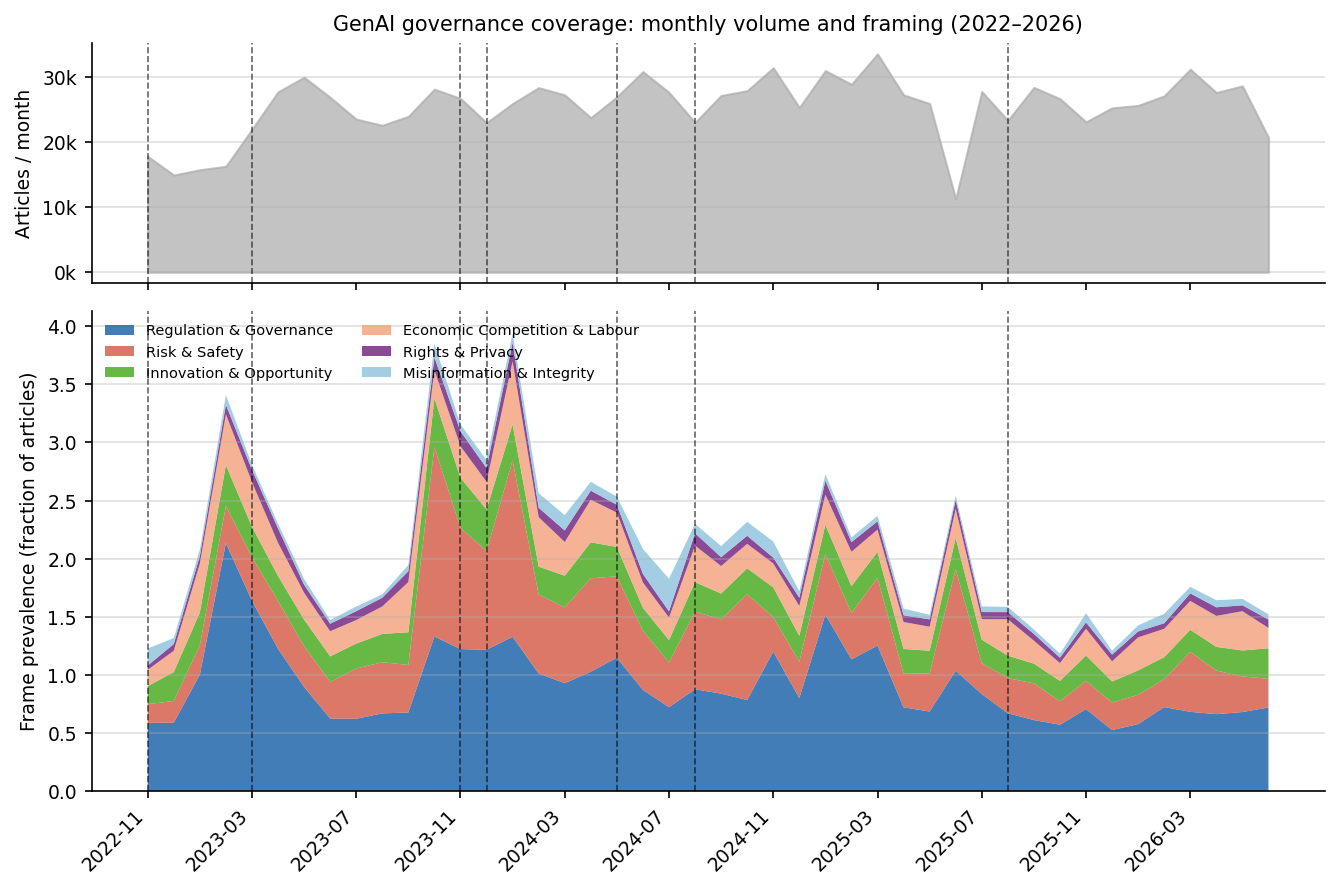

In [3]:
milestone_periods = {m["name"]: pd.Period(m["date"][:7], freq="M") for m in MILESTONES}

x_idx = shares.index.tolist()
x     = range(len(x_idx))

def _milestone_x(name: str) -> int | None:
    p = milestone_periods.get(name)
    return x_idx.index(p) if p in x_idx else None

fig, (ax_vol, ax_frames) = plt.subplots(2, 1, figsize=(9, 6), sharex=True,
                                         gridspec_kw={"height_ratios": [1, 2]})

# — Volume panel
ax_vol.fill_between(x, vol.reindex(x_idx).values, color="#aaaaaa", alpha=0.7)
ax_vol.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e3:.0f}k"))
ax_vol.set_ylabel("Articles / month")
ax_vol.set_title("GenAI governance coverage: monthly volume and framing (2022–2026)", fontsize=10)

# — Frame stacked area panel
frame_order = list(FRAME_COLORS.keys())
values = np.array([shares.reindex(x_idx)[f].values for f in frame_order if f in shares.columns])
labels = [FRAME_LABELS[f] for f in frame_order if f in shares.columns]
colors = [FRAME_COLORS[f] for f in frame_order if f in shares.columns]

ax_frames.stackplot(x, values, labels=labels, colors=colors, alpha=0.85)
ax_frames.set_ylabel("Frame prevalence (fraction of articles)")
ax_frames.legend(loc="upper left", fontsize=7, frameon=False, ncol=2)

# — Milestone lines on both panels
for name in milestone_periods:
    mx = _milestone_x(name)
    if mx is not None:
        for ax in (ax_vol, ax_frames):
            ax.axvline(mx, color="black", lw=0.8, ls="--", alpha=0.6)

ax_frames.set_xticks(x[::4])
ax_frames.set_xticklabels([str(x_idx[i]) for i in x[::4]], rotation=45, ha="right")

plt.tight_layout()
_save(fig, "fig_1_volume_frames")
plt.show()

## Fig 2 — Event studies

Regulation & Governance frame prevalence in the ±3-month window around each milestone.
One subplot per milestone, relative months on x-axis.

  Saved → paper/figures/fig_2_event_studies.pdf


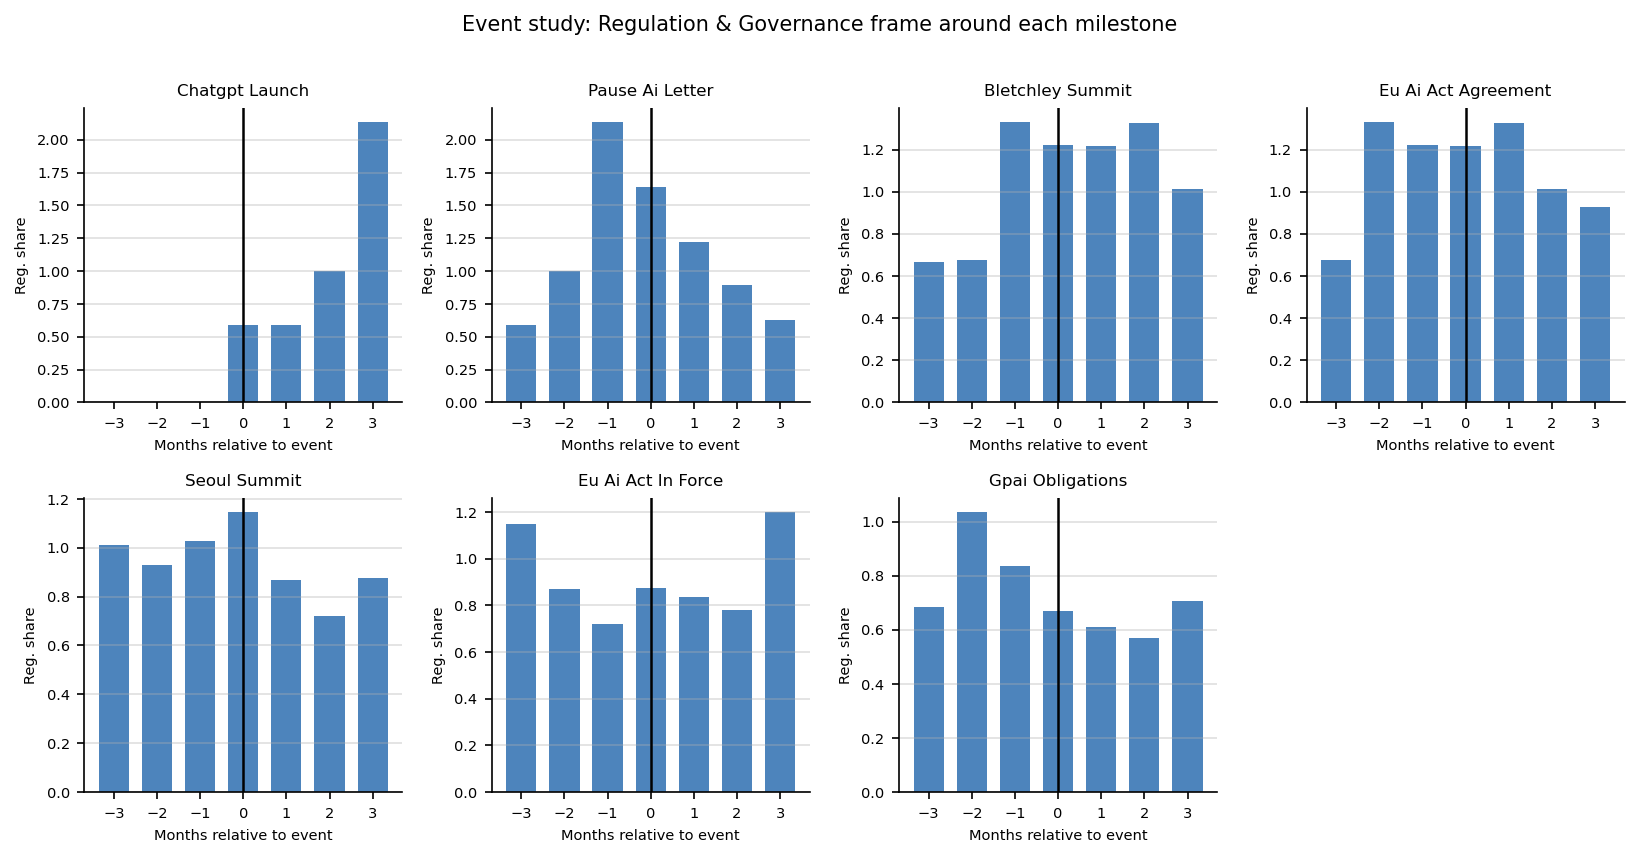

In [4]:
milestone_names = event_df["milestone"].unique()
n = len(milestone_names)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(11, 2.8 * nrows), sharey=False)
axes = axes.flatten()

TARGET_FRAME = "regulation_governance"

for i, mname in enumerate(milestone_names):
    sub = event_df[event_df["milestone"] == mname].sort_values("rel_month")
    ax = axes[i]
    rel = sub["rel_month"].values
    vals = sub[TARGET_FRAME].values if TARGET_FRAME in sub.columns else np.zeros(len(rel))

    ax.bar(rel, vals, color=FRAME_COLORS[TARGET_FRAME], alpha=0.8, width=0.7)
    ax.axvline(0, color="black", lw=1.2, ls="-")
    ax.set_title(mname.replace("_", " ").title(), fontsize=8)
    ax.set_xlabel("Months relative to event", fontsize=7)
    ax.set_ylabel("Reg. share", fontsize=7)
    ax.set_xticks(range(rel.min(), rel.max() + 1))
    ax.tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f"Event study: {FRAME_LABELS[TARGET_FRAME]} frame around each milestone",
             fontsize=10, y=1.01)
plt.tight_layout()
_save(fig, "fig_2_event_studies")
plt.show()

## Fig 3 — Regional frame comparison

Horizontal grouped bar chart: pooled frame prevalence rates by region (US, EU, UK).

  Saved → paper/figures/fig_3_regional.pdf


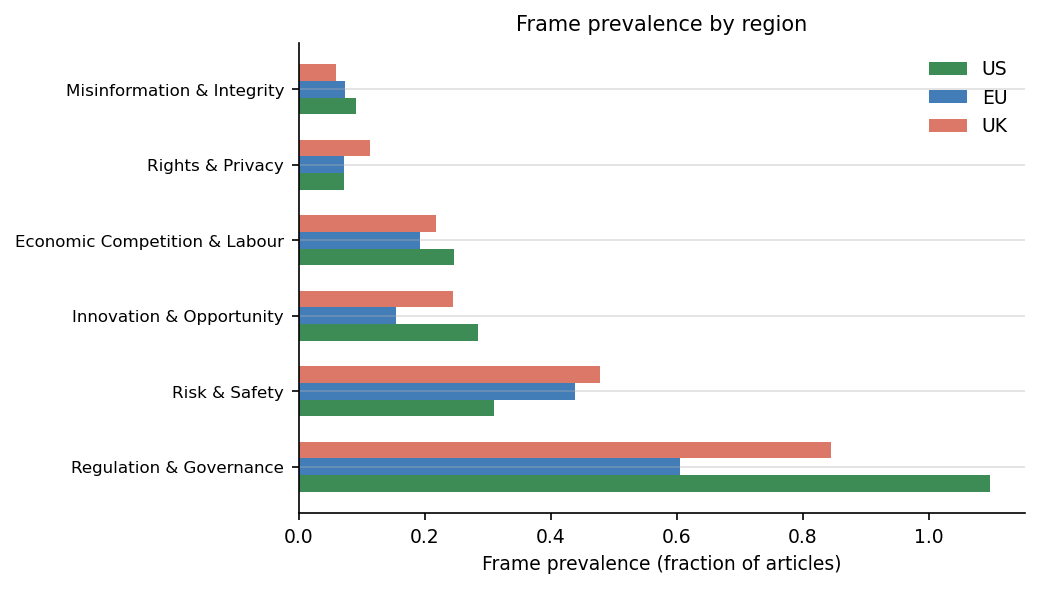

In [5]:
frames = [f for f in FRAME_COLORS if f in reg.columns]
present_regions = [r for r in REGIONS if r in reg.index]  # guard against missing region
n_present = len(present_regions)

fig, ax = plt.subplots(figsize=(7, 4))

y_base = np.arange(len(frames))
bar_h  = 0.22
offsets = np.linspace(-(n_present - 1) / 2, (n_present - 1) / 2, n_present) * bar_h

region_colors = {"US": "#1b7837", "EU": "#2166ac", "UK": "#d6604d"}

for j, region in enumerate(present_regions):
    vals = [reg.loc[region, f] if f in reg.columns else 0 for f in frames]
    ax.barh(y_base + offsets[j], vals, height=bar_h,
            color=region_colors.get(region, "gray"), label=region, alpha=0.85)

ax.set_yticks(y_base)
ax.set_yticklabels([FRAME_LABELS[f] for f in frames], fontsize=8)
ax.set_xlabel("Frame prevalence (fraction of articles)")
ax.set_title("Frame prevalence by region", fontsize=10)
ax.legend(frameon=False)
plt.tight_layout()
_save(fig, "fig_3_regional")
plt.show()

## Supplementary — Framing gap over time

EU−US regulation framing gap per quarter.

  Saved → paper/figures/fig_s1_framing_gap.pdf


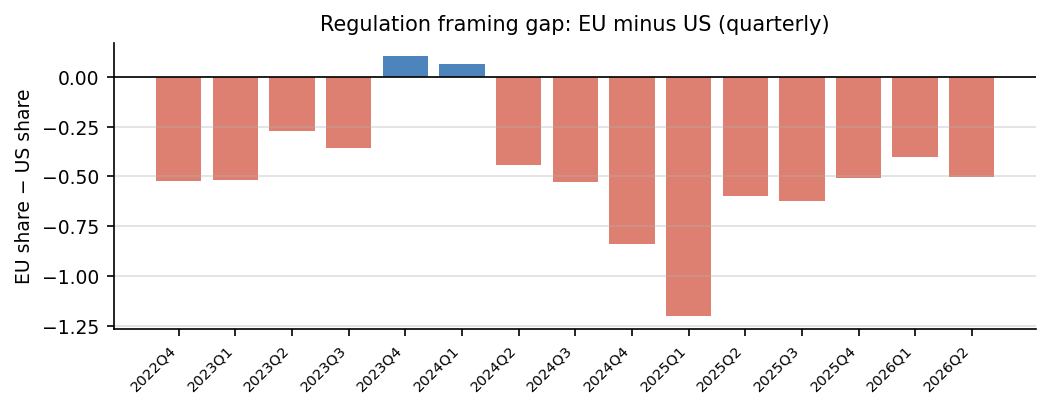

In [6]:
from src.analysis import framing_gap

df_preprocessed = pd.read_parquet(ROOT / "data" / "interim" / "gdelt_preprocessed.parquet")

gap = framing_gap(df_preprocessed, frame="regulation_governance",
                  region_a="EU", region_b="US", freq="Q")

fig, ax = plt.subplots(figsize=(7, 2.8))
x = range(len(gap))
ax.bar(x, gap.values,
       color=["#2166ac" if v >= 0 else "#d6604d" for v in gap.values],
       alpha=0.8)
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels([str(p) for p in gap.index], rotation=45, ha="right", fontsize=7)
ax.set_ylabel("EU share − US share")
ax.set_title("Regulation framing gap: EU minus US (quarterly)", fontsize=10)
plt.tight_layout()
_save(fig, "fig_s1_framing_gap")
plt.show()

## Supplementary — Tone analysis (GDELT V2Tone)

V2Tone is a keyword-count heuristic — interpret directionally, not as ground truth.
Three panels: (a) monthly mean tone trend with milestone markers; (b) mean tone ± 1σ by dominant frame; (c) mean tone by region.

  Saved → paper/figures/fig_s2_tone.pdf


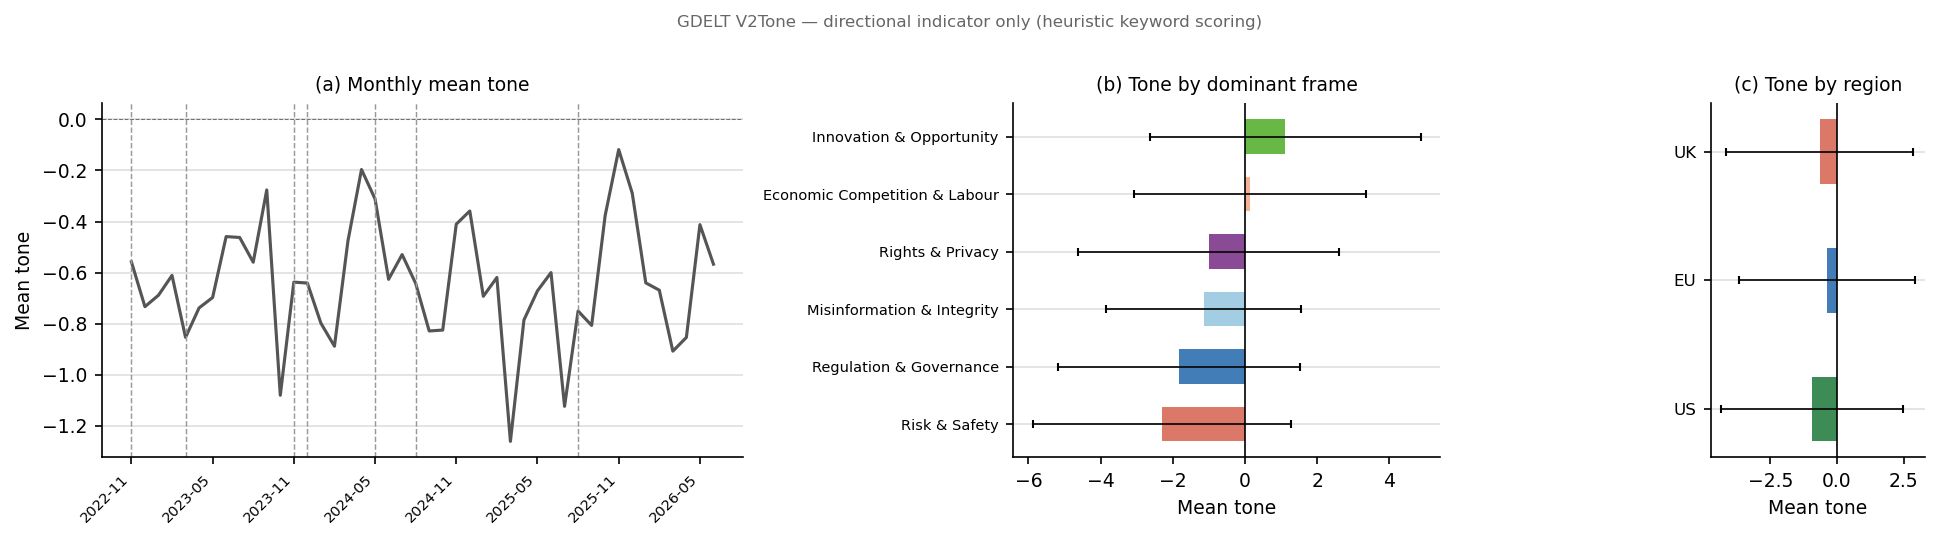

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5),
                         gridspec_kw={"width_ratios": [3, 2, 1]})

# ── (a) Monthly tone trend ────────────────────────────────────────────────────
ax = axes[0]
x_idx = tone_monthly.index.tolist()
x = range(len(x_idx))
ax.plot(x, tone_monthly.values, color="#555555", lw=1.5)
ax.axhline(0, color="black", lw=0.5, ls="--", alpha=0.5)

# Milestone lines
for m in MILESTONES:
    p = pd.Period(m["date"][:7], freq="M")
    if p in x_idx:
        ax.axvline(x_idx.index(p), color="#999999", lw=0.7, ls="--")

ax.set_xticks(list(x)[::6])
ax.set_xticklabels([str(x_idx[i]) for i in list(x)[::6]], rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Mean tone")
ax.set_title("(a) Monthly mean tone", fontsize=9)

# ── (b) Tone by dominant frame ────────────────────────────────────────────────
ax = axes[1]
tf = tone_frame.sort_values("mean")
frame_names = tf.index.tolist()
y = range(len(frame_names))
colors = [FRAME_COLORS.get(f, "#aaaaaa") for f in frame_names]
ax.barh(y, tf["mean"].values, xerr=tf["std"].values,
        color=colors, alpha=0.85, height=0.6,
        error_kw={"elinewidth": 0.8, "capsize": 2})
ax.axvline(0, color="black", lw=0.8)
ax.set_yticks(y)
ax.set_yticklabels([FRAME_LABELS.get(f, f) for f in frame_names], fontsize=7)
ax.set_xlabel("Mean tone")
ax.set_title("(b) Tone by dominant frame", fontsize=9)

# ── (c) Tone by region ────────────────────────────────────────────────────────
ax = axes[2]
region_colors = {"US": "#1b7837", "EU": "#2166ac", "UK": "#d6604d"}
tr = tone_region.reindex([r for r in REGIONS if r in tone_region.index])
y = range(len(tr))
ax.barh(y, tr["mean"].values, xerr=tr["std"].values,
        color=[region_colors.get(r, "#aaaaaa") for r in tr.index],
        alpha=0.85, height=0.5,
        error_kw={"elinewidth": 0.8, "capsize": 2})
ax.axvline(0, color="black", lw=0.8)
ax.set_yticks(y)
ax.set_yticklabels(tr.index.tolist(), fontsize=8)
ax.set_xlabel("Mean tone")
ax.set_title("(c) Tone by region", fontsize=9)

plt.suptitle("GDELT V2Tone — directional indicator only (heuristic keyword scoring)",
             fontsize=8, color="#666666", y=1.01)
plt.tight_layout()
_save(fig, "fig_s2_tone")
plt.show()

## Supplementary — Source concentration

  Saved → paper/figures/fig_s3_sources.pdf


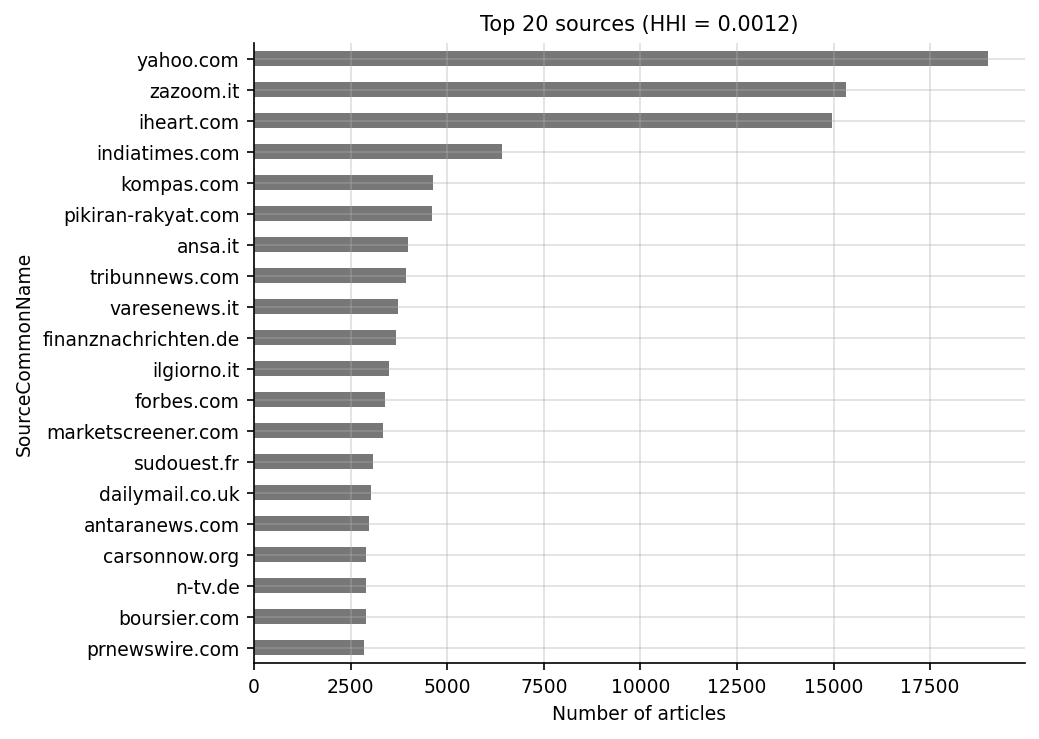

In [8]:
from src.analysis import source_concentration

top_sources, hhi = source_concentration(df_preprocessed, top_n=20)

fig, ax = plt.subplots(figsize=(7, 5))
top_sources[::-1].plot.barh(ax=ax, color="#555555", alpha=0.8)
ax.set_xlabel("Number of articles")
ax.set_title(f"Top 20 sources (HHI = {hhi:.4f})", fontsize=10)
plt.tight_layout()
_save(fig, "fig_s3_sources")
plt.show()

## Supplementary — ML frame validation (Fig S4)

Only rendered if `02_ml_framing.ipynb` has been run
(requires `data/processed/ml_frame_scores_embedding.parquet`).

**Fig S4** — Distribution of bipolar LaBSE embedding scores for keyword-matched vs. unmatched
articles per frame. Validates that dictionary-based frame flags correspond to semantically
distinct regions of embedding space.

Loaded embedding sample: 1,116,091 articles
  Saved → paper/figures/fig_s4_embedding_validation.pdf


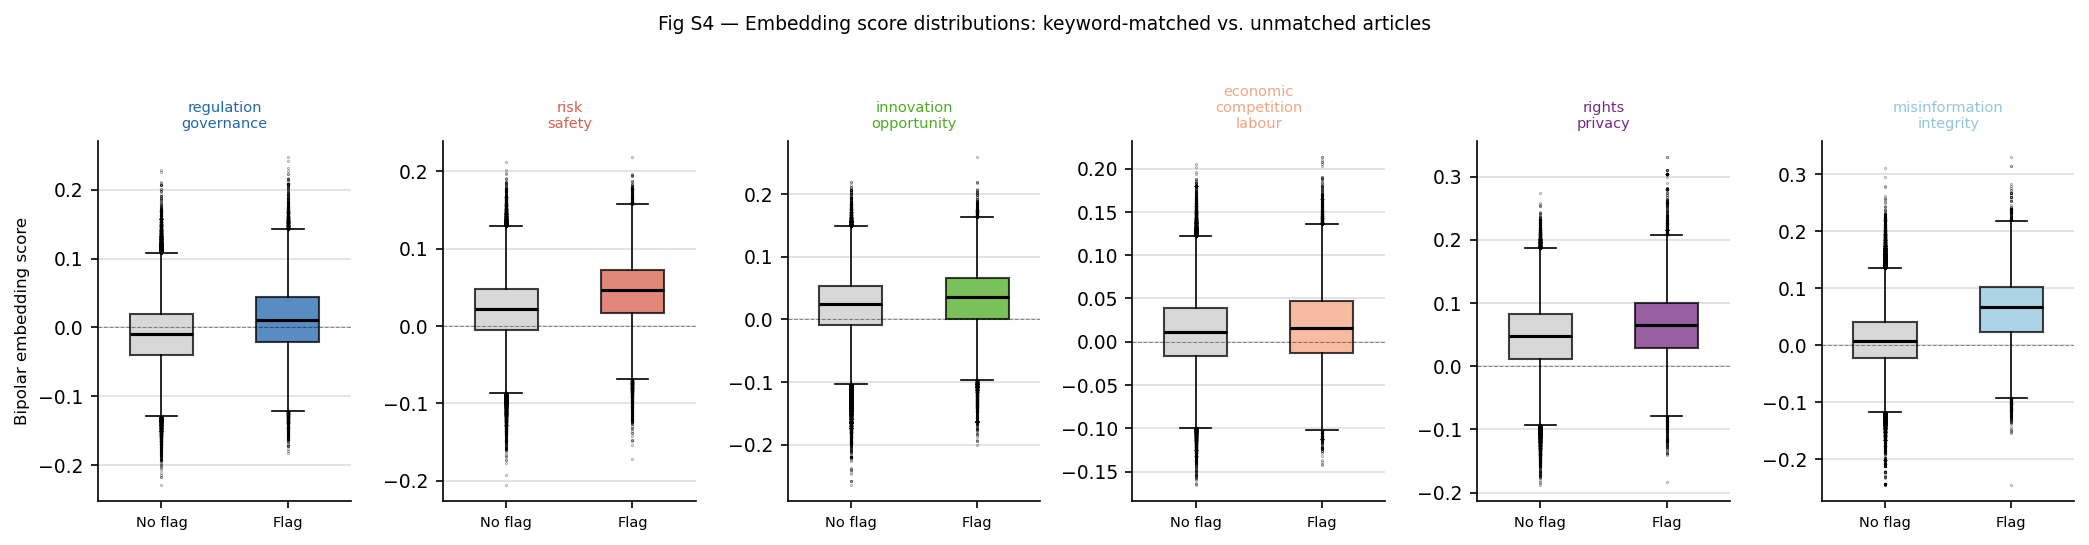

In [10]:
ML_EMBEDDING_PATH = PROCESSED / "ml_frame_scores_embedding_full.parquet"
FRAME_NAMES = list(FRAME_COLORS.keys())

if not ML_EMBEDDING_PATH.exists():
    print("ml_frame_scores_embedding_full.parquet not found — run 02_ml_framing.ipynb first.")
else:
    emb = pd.read_parquet(ML_EMBEDDING_PATH)
    print(f"Loaded embedding sample: {len(emb):,} articles")

    fig, axes = plt.subplots(1, len(FRAME_NAMES), figsize=(14, 3.5))

    for j, name in enumerate(FRAME_NAMES):
        ax = axes[j]
        col_kw = f"frame_{name}"
        if name not in emb.columns or col_kw not in emb.columns:
            ax.set_visible(False)
            continue

        has_flag = emb[col_kw] > 0
        groups = [emb.loc[~has_flag, name].dropna().values,
                  emb.loc[has_flag,  name].dropna().values]
        bp = ax.boxplot(groups, widths=0.5, patch_artist=True,
                        medianprops={"color": "black", "lw": 1.5},
                        flierprops={"marker": ".", "markersize": 1, "alpha": 0.3},
                        whiskerprops={"lw": 0.8}, capprops={"lw": 0.8})
        bp["boxes"][0].set_facecolor("#cccccc")
        bp["boxes"][1].set_facecolor(FRAME_COLORS.get(name, "#2166ac"))
        for box in bp["boxes"]:
            box.set_alpha(0.75)
        ax.set_xticks([1, 2])
        ax.set_xticklabels(["No flag", "Flag"], fontsize=7)
        ax.set_title(name.replace("_", "\n"), fontsize=7,
                     color=FRAME_COLORS.get(name, "#555555"))
        if j == 0:
            ax.set_ylabel("Bipolar embedding score", fontsize=8)
        ax.axhline(0, color="black", lw=0.5, ls="--", alpha=0.4)

    fig.suptitle("Fig S4 — Embedding score distributions: keyword-matched vs. unmatched articles",
                 fontsize=9, y=1.02)
    plt.tight_layout()
    _save(fig, "fig_s4_embedding_validation")
    plt.show()

## Supplementary — Confirmed frame trends (Fig S5)

Only rendered if `02_ml_framing.ipynb` Section 4 has been run with `SAMPLE_N = None`
(requires `data/processed/ml_frame_confirmed.parquet`).

**Fig S5** — Side-by-side comparison of monthly frame prevalence: keyword-only (left) vs.
confirmed frames (keyword ∩ embedding score > 0, right). A robustness check: if the temporal
patterns agree, the keyword-based trends are unlikely to be artefacts of incidental term matches.

  Saved → paper/figures/fig_s5_confirmed_frames.pdf


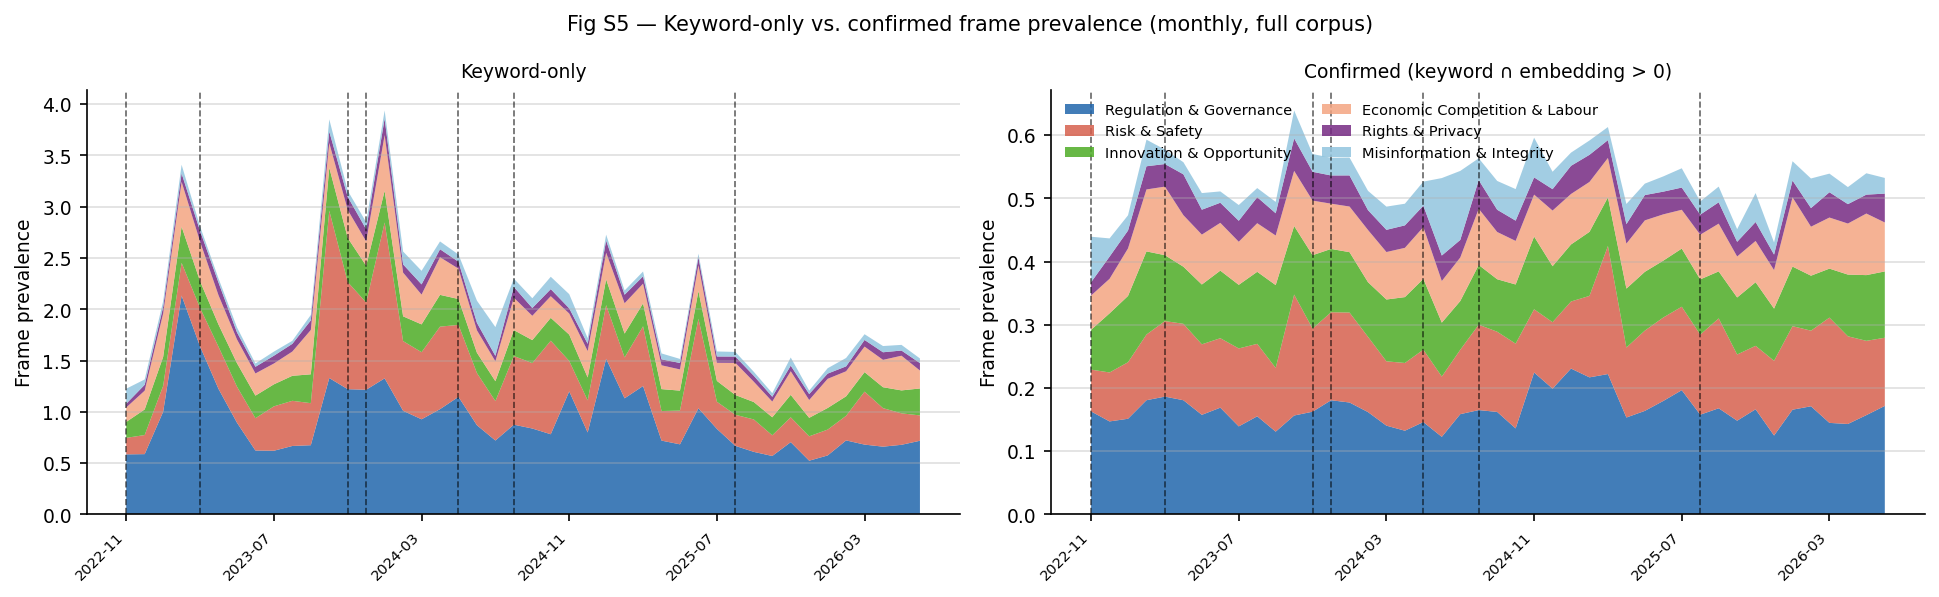

In [11]:
ML_CONFIRMED_PATH = PROCESSED / "ml_frame_confirmed.parquet"

if not ML_CONFIRMED_PATH.exists():
    print("ml_frame_confirmed.parquet not found — run 02_ml_framing.ipynb Section 4 (SAMPLE_N=None) first.")
else:
    from src.analysis import frame_shares

    conf = pd.read_parquet(ML_CONFIRMED_PATH)
    conf["month"] = conf["month"].apply(
        lambda x: pd.Period(x, freq="M") if isinstance(x, str) else x
    )
    monthly_conf = frame_shares(conf, month_col="month")

    x_idx = shares.index.tolist()
    x = range(len(x_idx))
    frame_order = list(FRAME_COLORS.keys())

    fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

    for ax, (data, title) in zip(axes, [
        (shares,       "Keyword-only"),
        (monthly_conf, "Confirmed (keyword ∩ embedding > 0)"),
    ]):
        values = [data.reindex(x_idx).get(f, pd.Series(0.0, index=x_idx)).values
                  for f in frame_order]
        ax.stackplot(x, values,
                     labels=[FRAME_LABELS[f] for f in frame_order],
                     colors=[FRAME_COLORS[f] for f in frame_order], alpha=0.85)
        for m in MILESTONES:
            p = pd.Period(m["date"][:7], freq="M")
            if p in x_idx:
                ax.axvline(x_idx.index(p), color="black", lw=0.8, ls="--", alpha=0.6)
        ax.set_xticks(list(x)[::8])
        ax.set_xticklabels([str(x_idx[i]) for i in list(x)[::8]],
                            rotation=45, ha="right", fontsize=7)
        ax.set_ylabel("Frame prevalence")
        ax.set_title(title, fontsize=9)

    axes[1].legend(loc="upper left", fontsize=7, frameon=False, ncol=2)
    fig.suptitle("Fig S5 — Keyword-only vs. confirmed frame prevalence (monthly, full corpus)",
                 fontsize=10)
    plt.tight_layout()
    _save(fig, "fig_s5_confirmed_frames")
    plt.show()

## Supplementary — Monthly embedding trends (full corpus)

Only rendered if `02_ml_framing.ipynb` has been run with `SAMPLE_N = None`
(requires `data/processed/ml_frame_scores_embedding_full.parquet`).

**Fig S6** — Monthly mean bipolar embedding score per frame across the full 1.1M article corpus.
Parallels Fig 1 (keyword prevalence) but derived entirely from LaBSE cosine similarity — a
robustness check on the temporal trends.

  Saved → paper/figures/fig_s6_monthly_embedding.pdf


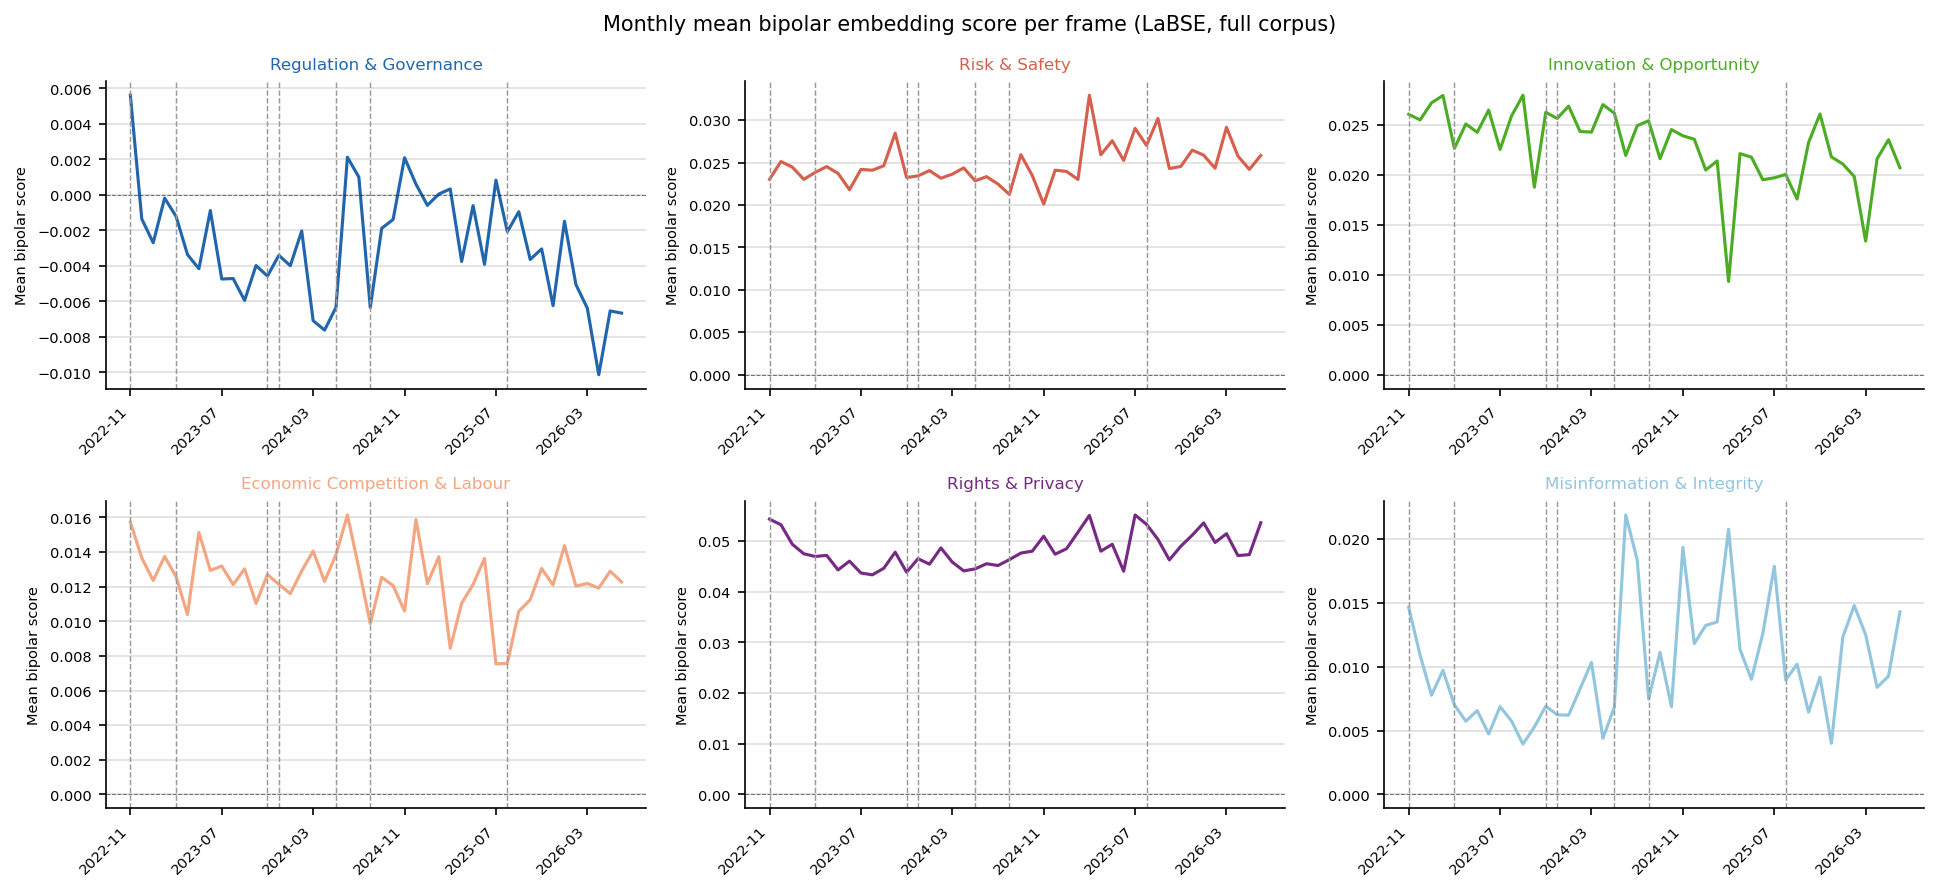

In [12]:
ML_EMBEDDING_FULL_PATH = PROCESSED / "ml_frame_scores_embedding_full.parquet"

if not ML_EMBEDDING_FULL_PATH.exists():
    print("ml_frame_scores_embedding_full.parquet not found — run 02_ml_framing.ipynb with SAMPLE_N=None first.")
else:
    emb_full = pd.read_parquet(ML_EMBEDDING_FULL_PATH)
    monthly_emb = emb_full.groupby("month")[FRAME_NAMES].mean().sort_index()
    idx_list = monthly_emb.index.tolist()

    fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharey=False)
    axes = axes.flatten()

    for j, name in enumerate(FRAME_NAMES):
        ax = axes[j]
        x = range(len(idx_list))
        ax.plot(x, monthly_emb[name].values,
                color=FRAME_COLORS.get(name, "#555555"), lw=1.5)
        ax.axhline(0, color="black", lw=0.5, ls="--", alpha=0.5)

        for m in MILESTONES:
            p = pd.Period(m["date"][:7], freq="M")
            if p in idx_list:
                ax.axvline(idx_list.index(p), color="#999999", lw=0.7, ls="--")

        ax.set_xticks(list(x)[::8])
        ax.set_xticklabels(
            [str(idx_list[i]) for i in list(x)[::8]], rotation=45, ha="right", fontsize=7
        )
        ax.set_ylabel("Mean bipolar score", fontsize=7)
        ax.set_title(FRAME_LABELS.get(name, name), fontsize=8,
                     color=FRAME_COLORS.get(name, "#555555"))
        ax.tick_params(labelsize=7)

    fig.suptitle("Monthly mean bipolar embedding score per frame (LaBSE, full corpus)", fontsize=10)
    plt.tight_layout()
    _save(fig, "fig_s6_monthly_embedding")
    plt.show()